# 1. Imports

In [1]:
import pandas as pd                 # Manejar DataFrames
from pathlib import Path            # Manejar rutas
import matplotlib.pyplot as plt     # Gráficos matplotlib
import seaborn as sns               # Gráficos seaborn
import numpy as np                  # Cálculos con numpy

# 2. Get data

Obtener dirección de carpetas necesarias

In [2]:
PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic


In [3]:
FIGURES_PATH = PROJECT_ROOT / 'outputs' / 'figures'
print(FIGURES_PATH)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\2_titanic\outputs\figures


Leer train

In [4]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'train.csv')

# 3. Initial analysis

Info

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Head

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Describe

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4. Raw EDA

Esto será una exploración inicial de los datos sucios

Vamos a generar una constante para siempre organizar en orden 0-1, o sea "Not survived" y "Survived". Otra constante para el orden en palabras. Y otra para definir colores para cada valor.

In [8]:
SURVIVED_ORDER = [0, 1]
SURVIVED_ORDER_STR = ['Not survived', 'Survived']
SURVIVED_COLORS = ["#ff4343", "#3a68fd"]

Además crearemos un DataFrame que de sobrevivientes y otro de no sobrevivientes, lo cual puede ayudar en ciertos casos.

In [9]:
df_survivors = df[df['Survived'] == 1].copy()
df_no_survivors = df[df['Survived'] == 0].copy()

## 4.1 Survival distribution

Contar

In [10]:
count_survived = df['Survived'].value_counts().reindex(SURVIVED_ORDER)
count_survived

Survived
0    549
1    342
Name: count, dtype: int64

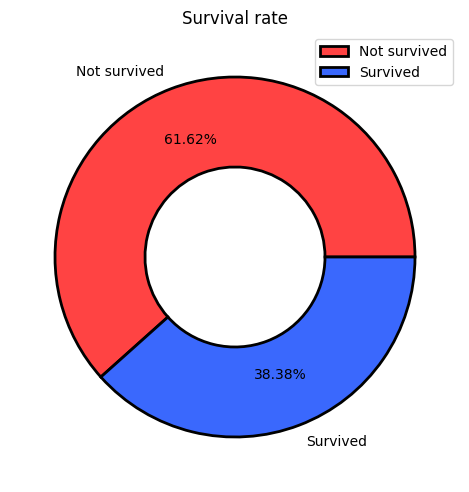

In [11]:
plt.pie(
    count_survived,
    labels=['Not survived', 'Survived'],
    autopct='%1.2f%%',
    pctdistance=0.7,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 2,
        'width': 0.5
    },
    colors=SURVIVED_COLORS
)

plt.legend()
plt.tight_layout()
plt.title('Survival rate')

plt.savefig(FIGURES_PATH / '01_survival_rate.png', bbox_inches='tight')
plt.show()

## 4.2 Pclass

### 4.2.1 Proportions of Pclass

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
count_total_pclass = df['Pclass'].value_counts().reindex([1, 2, 3])
count_total_pclass

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

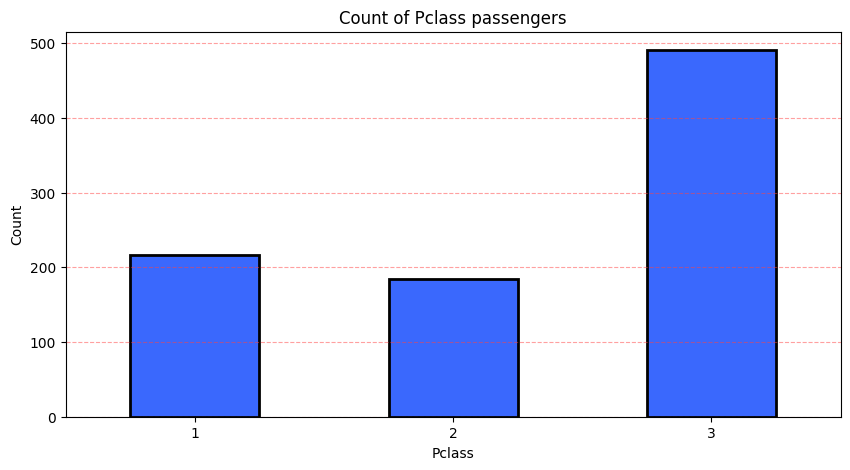

In [14]:
plt.figure(figsize=(10, 5))

count_total_pclass.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2

)
plt.grid(axis='y', linestyle='--', alpha=0.5, color=SURVIVED_COLORS[0])

plt.xticks(rotation=0)

plt.xlabel('Pclass')
plt.ylabel('Count')
plt.title('Count of Pclass passengers')


plt.savefig(FIGURES_PATH / '02_count_pclass.png', bbox_inches='tight')
plt.show()

### 4.2.2 Survived rate by Pclass

Contar por cada tipo de Pclass

In [15]:
count_pclass_1 = df[df['Pclass'] == 1]['Survived'].value_counts()
count_pclass_1

Survived
1    136
0     80
Name: count, dtype: int64

In [16]:
count_pclass_2 = df[df['Pclass'] == 2]['Survived'].value_counts()
count_pclass_2

Survived
0    97
1    87
Name: count, dtype: int64

In [17]:
count_pclass_3 = df[df['Pclass'] == 3]['Survived'].value_counts()
count_pclass_3

Survived
0    372
1    119
Name: count, dtype: int64

Visualizar cada proporción

In [18]:
pclass_groups_data = [count_pclass_1, count_pclass_2, count_pclass_3]
pclass_options = ['Pclass 1', 'Pclass 2', 'Pclass 3']

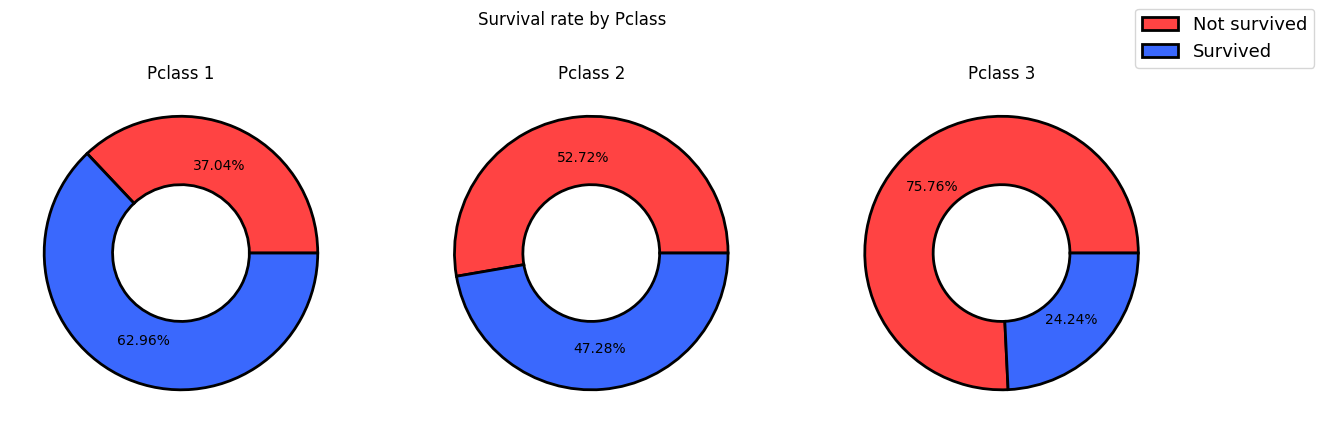

In [19]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# Iterar sobre cada grupo, obteniendo indice para el axes y nombre de la pclass (se hace reindex para ordenar la data en orden 0-1)
for i, (data, pclass) in enumerate(zip(pclass_groups_data, pclass_options)):
    data = data.reindex(SURVIVED_ORDER)
    ax[i].pie(
        data,
        colors=SURVIVED_COLORS,
        autopct='%1.2f%%',
        wedgeprops={
            'width': 0.5,
            'edgecolor': 'black',
            'linewidth': 2
        },
        pctdistance=0.7,
    )
    ax[i].set_title(pclass, pad=-50)

fig.legend(SURVIVED_ORDER_STR, fontsize='13')

fig.suptitle('Survival rate by Pclass')

plt.savefig(FIGURES_PATH / '03_survival_rate_by_pclass', bbox_inches='tight')
plt.show()

## 4.3 Sex

### 4.3.1 Sex distribution

In [20]:
count_sex = df['Sex'].value_counts()
count_sex

Sex
male      577
female    314
Name: count, dtype: int64

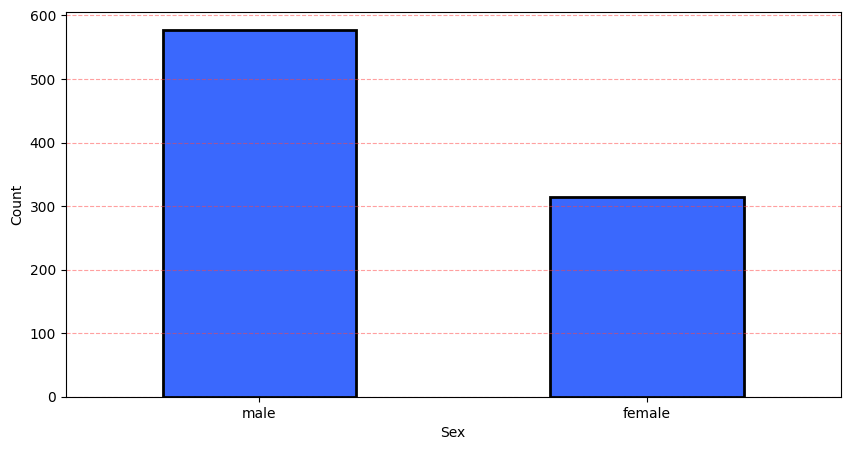

In [21]:
plt.figure(figsize=(10, 5))

count_sex.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color=SURVIVED_COLORS[0])

plt.xticks(rotation=0)

plt.xlabel('Sex')
plt.ylabel('Count')

plt.savefig(FIGURES_PATH / '04_count_sex.png', bbox_inches='tight')
plt.show()

### 4.3.2 Survived rate by Sex

In [22]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
group_sex_survived = df.groupby('Sex')['Survived'].value_counts().unstack()
group_sex_survived

Survived,0,1
Sex,,
female,81,233
male,468,109


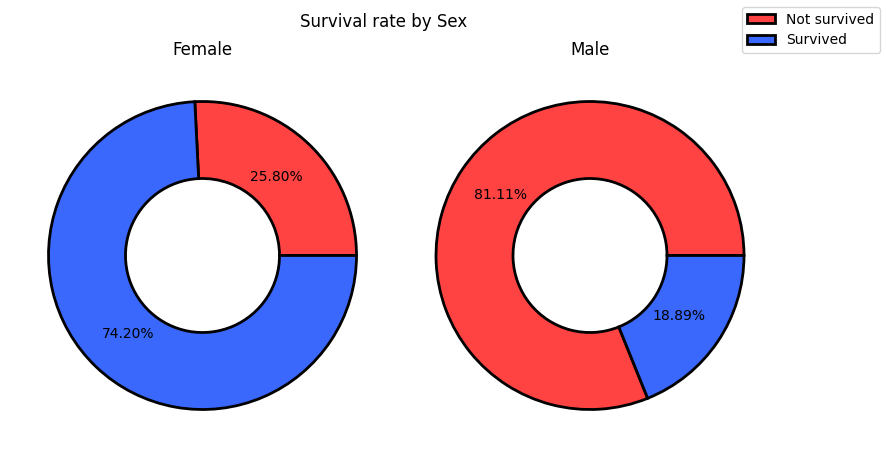

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

for i, sex in enumerate(group_sex_survived.index):
    survival_values = group_sex_survived.loc[sex]
    survival_values = survival_values.reindex(SURVIVED_ORDER)

    ax[i].pie(
        survival_values,
        colors=SURVIVED_COLORS,
        autopct='%1.2f%%',
        pctdistance=0.7,
        wedgeprops={
            'width': 0.5,
            'linewidth': 2,
            'edgecolor': 'black'
        }
    )
    ax[i].set_title(sex.capitalize())

fig.subplots_adjust(wspace=0)
fig.legend(SURVIVED_ORDER_STR)
fig.suptitle('Survival rate by Sex')

plt.savefig(FIGURES_PATH / '05_survival_rate_by_sex.png', bbox_inches='tight')
plt.show()

## 4.4 Age

### 4.4.1 Age distribution

In [25]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


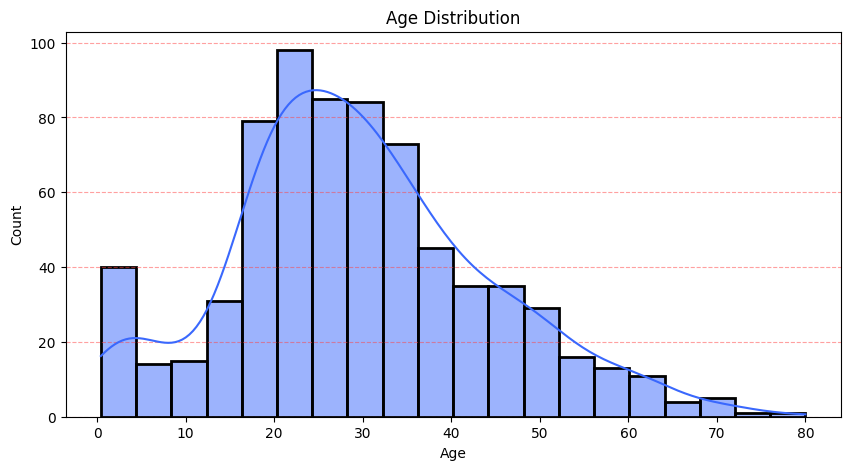

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Age'],
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2,
    kde=True
)

plt.grid(axis='y', linestyle='--', alpha=0.5, color=SURVIVED_COLORS[0])

plt.title('Age Distribution')

plt.savefig(FIGURES_PATH / '06_age_distribution.png')
plt.show()

### 4.4.2 Age distribution in survivors/no survivors

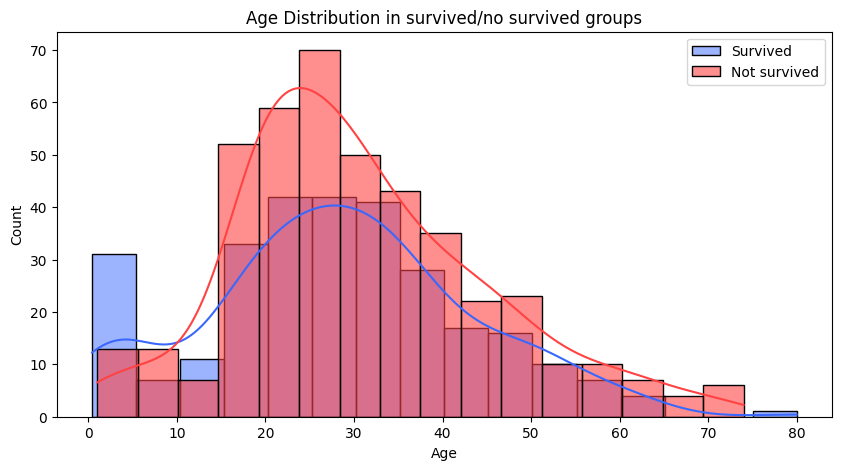

In [27]:
plt.figure(figsize=(10, 5))


sns.histplot(
    df_survivors['Age'],
    color=SURVIVED_COLORS[1],
    label='Survived',
    kde=True
)

sns.histplot(
    df_no_survivors['Age'],
    color=SURVIVED_COLORS[0],
    alpha=0.6,
    label='Not survived',
    kde=True
)

plt.legend()

plt.title('Age Distribution in survived/no survived groups')

plt.savefig(FIGURES_PATH / '06_01_age_distribution_in_survived_no_survived_groups.png')
plt.show()

### 4.4.3 See age groups survivors rates

Dividiremos en grupos cada 10 años para ver probabilidades de sobrevivir

In [28]:
bins = [i for i in range(0, 100, 10)]

age_groups = pd.cut(df['Age'], bins=bins)

# observed=True es para que si hay un grupo que no tiene ningún registro, no considera ese grupo
age_group_surv_rate = df.groupby(age_groups, observed=True)['Survived'].mean()
age_group_surv_rate

Age
(0, 10]     0.593750
(10, 20]    0.382609
(20, 30]    0.365217
(30, 40]    0.445161
(40, 50]    0.383721
(50, 60]    0.404762
(60, 70]    0.235294
(70, 80]    0.200000
Name: Survived, dtype: float64

Ahora graficar

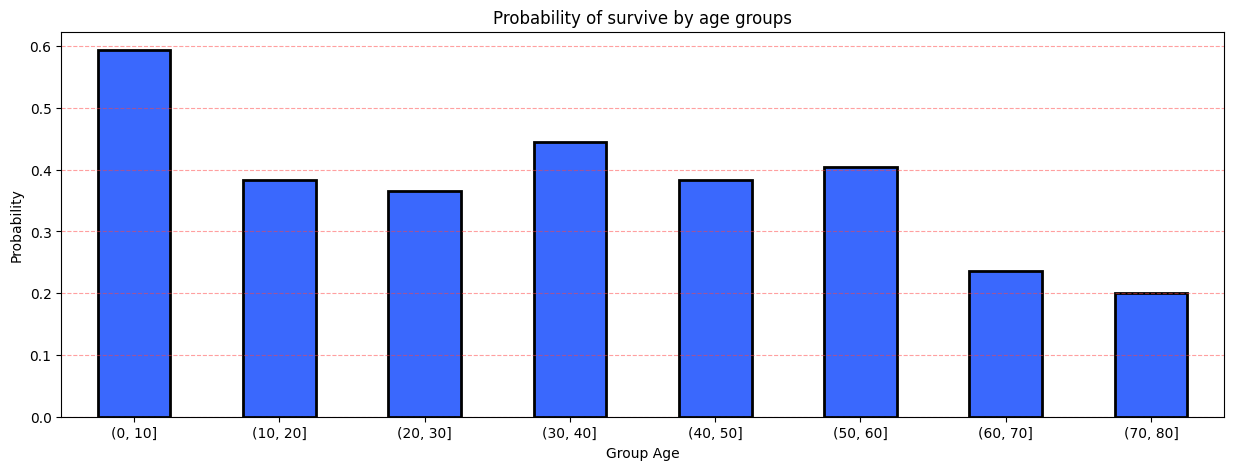

In [29]:
plt.figure(figsize=(15, 5))

age_group_surv_rate.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

plt.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.5)

plt.xlabel('Group Age')
plt.ylabel('Probability')

plt.xticks(rotation=0)

plt.title('Probability of survive by age groups')

plt.savefig(FIGURES_PATH / '07_probability_of_survive_by_age_groups.png', bbox_inches='tight')
plt.show()

## 4.5 SibSp

In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Contar cada categoría

In [31]:
value_counts_of_sibsp = df['SibSp'].value_counts()
value_counts_of_sibsp

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

Obtener probabilidades de sobrevivencia de cada uno

In [32]:
sibsp_group_surv_rate = df.groupby('SibSp')['Survived'].mean()
sibsp_group_surv_rate

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

Graficar

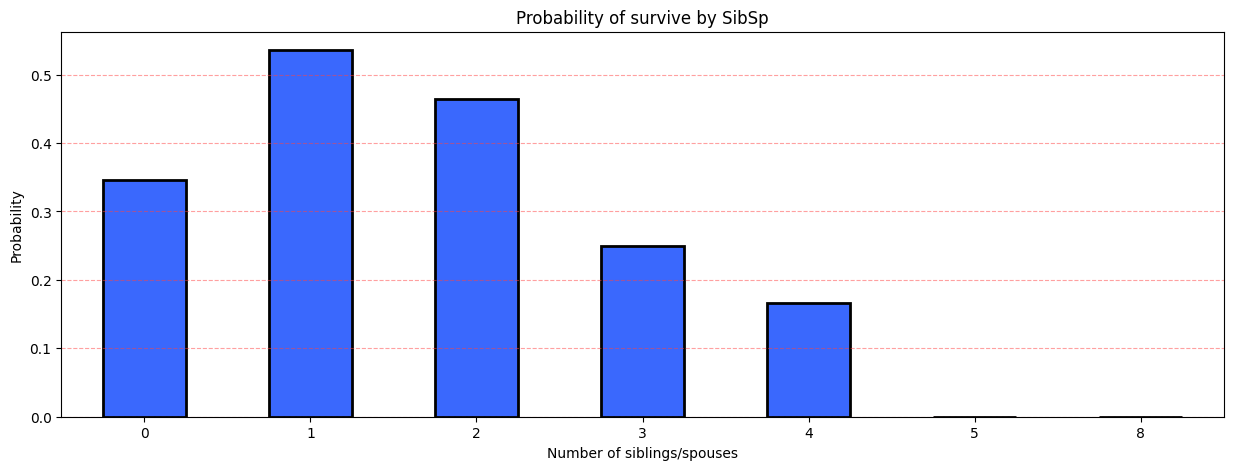

In [33]:
plt.figure(figsize=(15, 5))

sibsp_group_surv_rate.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

plt.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.5)

plt.xlabel('Number of siblings/spouses')
plt.ylabel('Probability')

plt.xticks(rotation=0)

plt.title('Probability of survive by SibSp')

plt.savefig(FIGURES_PATH / '08_probability_of_survive_by_sibsp.png', bbox_inches='tight')
plt.show()

## 4.6 Parch

In [34]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Contar categorías

In [35]:
value_counts_of_parch = df['Parch'].value_counts()
value_counts_of_parch

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

Ver probabilidades de sobreviviencia

In [36]:
parch_group_surv_rate = df.groupby('Parch')['Survived'].mean()
parch_group_surv_rate

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

Graficar

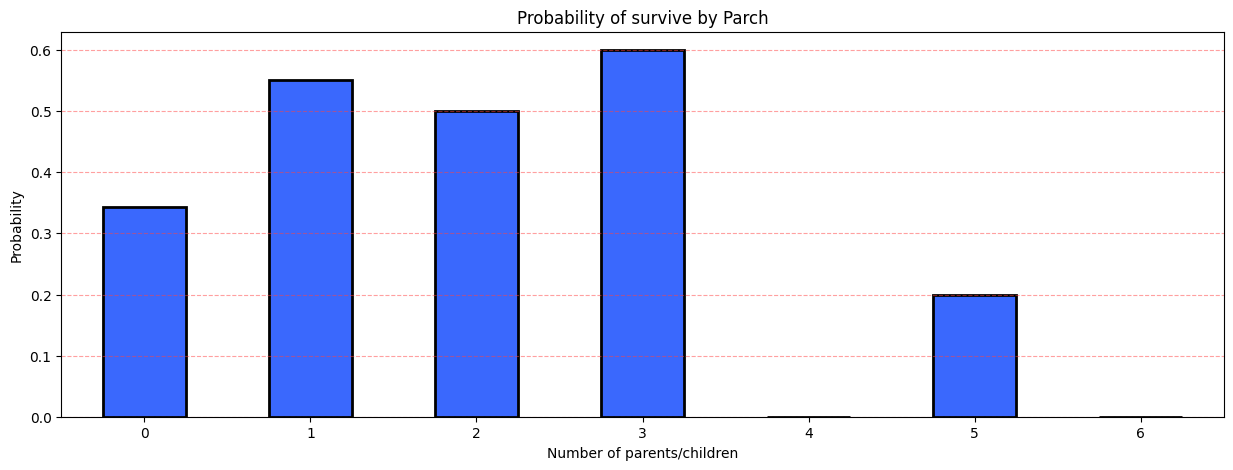

In [37]:
plt.figure(figsize=(15, 5))

parch_group_surv_rate.plot(
    kind='bar',
    color=SURVIVED_COLORS[1],
    edgecolor='black',
    linewidth=2
)

plt.grid(axis='y', color=SURVIVED_COLORS[0], linestyle='--', alpha=0.5)

plt.title('Probability of survive by Parch')

plt.xlabel('Number of parents/children')
plt.ylabel('Probability')

plt.xticks(rotation=0)


plt.savefig(FIGURES_PATH / '09_probability_of_survive_by_parch.png', bbox_inches='tight')
plt.show()

## 4.7 Fare

### 4.7.1 Fare distribution histogram

In [38]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


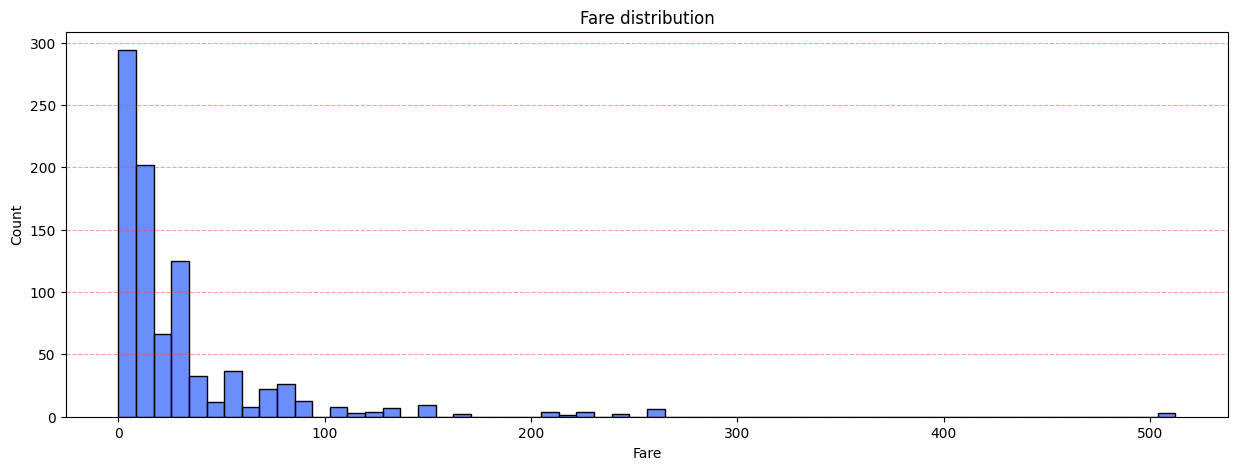

In [39]:
plt.figure(figsize=(15, 5))

sns.histplot(
    df['Fare'],
    color=SURVIVED_COLORS[1]
)

plt.grid(axis='y', linestyle='--', color=SURVIVED_COLORS[0], alpha=0.5)

plt.title('Fare distribution')

plt.savefig(FIGURES_PATH / '10_fare_distribution.png', bbox_inches='tight')
plt.show()

### 4.7.2 Fare distribution in no survivors and survivors

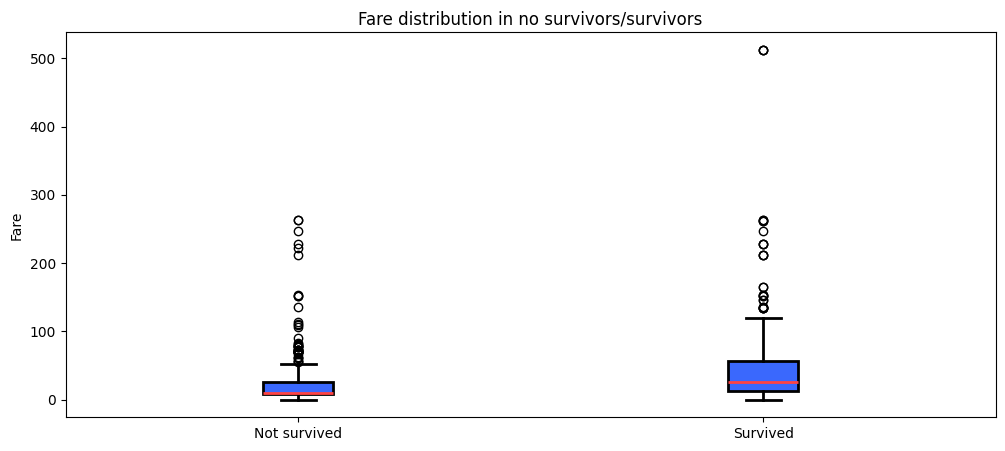

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.boxplot(
    [df_no_survivors['Fare'], df_survivors['Fare']],
    tick_labels=SURVIVED_ORDER_STR,
    patch_artist=True,                                   # Habilitar relleno de cajas

    boxprops={                                           # Propiedades de la caja
        'facecolor': SURVIVED_COLORS[1],                 # Color de la caja
        'edgecolor': 'black',                            # Color borde de la caja
        'linewidth': 2                                   # Grosor borde de la caja
    },

    medianprops={                                        # Propiedades de la linea de mediana
        'color': SURVIVED_COLORS[0],                     # Color
        'linewidth': 2                                   # Grosor
    },

    whiskerprops={                                       # Propiedades de los bigotes
        'color': 'black',                                # Color
        'linewidth': 2                                   # Grosor
    },

    capprops={                                           # Propiedades de las barras horizontales al final de los bigotes
        'color': 'black',                                # Color
        'linewidth': 2                                   # Grosor
    }
)

plt.ylabel('Fare')

plt.title('Fare distribution in no survivors/survivors')

plt.savefig(FIGURES_PATH / '11_fare_dist_boxplot_surv_no_surv.png', bbox_inches='tight')
plt.show()

### 4.7.3 Log Fare distribution in no survivors and survivors

Para poder ver más explicitamente las diferencias de los grupos, aplicaremos logaritmo en los fare de cada grupo.

In [41]:
df_log_fare_survivors = df_survivors.copy()
df_log_fare_no_survivors = df_no_survivors.copy()

# Se utilizó log1p ya que hay fare en 0 y el log de 0 daría -infinito, asi que log1p hacer log(x + 1)
df_log_fare_survivors['Fare'] = np.log1p(df_log_fare_survivors['Fare'])
df_log_fare_no_survivors['Fare'] = np.log1p(df_log_fare_no_survivors['Fare'])

Graficar (aplicar misma lógica de gráfico anterior)

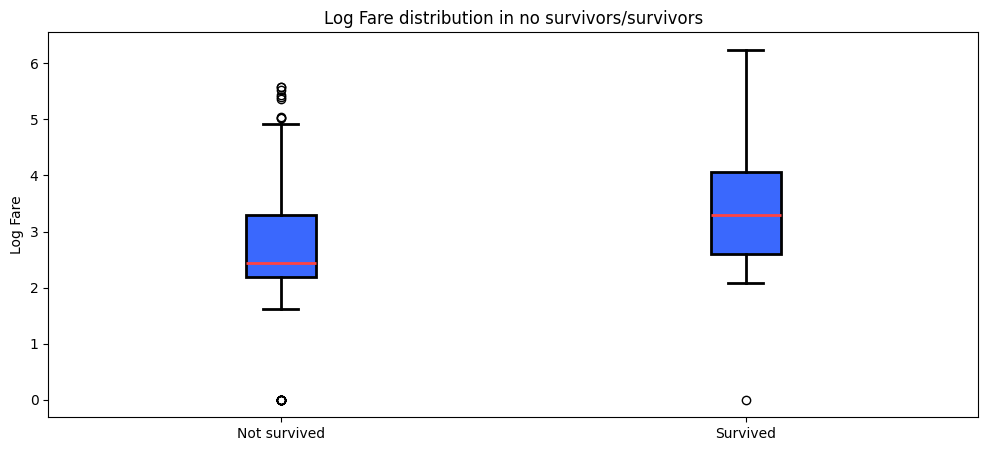

In [42]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.boxplot(
    [df_log_fare_no_survivors['Fare'], df_log_fare_survivors['Fare']],
    tick_labels=SURVIVED_ORDER_STR,
    patch_artist=True,                                   # Habilitar relleno de cajas

    boxprops={                                           # Propiedades de la caja
        'facecolor': SURVIVED_COLORS[1],                 # Color de la caja
        'edgecolor': 'black',                            # Color borde de la caja
        'linewidth': 2                                   # Grosor borde de la caja
    },

    medianprops={                                        # Propiedades de la linea de mediana
        'color': SURVIVED_COLORS[0],                     # Color
        'linewidth': 2                                   # Grosor
    },

    whiskerprops={                                       # Propiedades de los bigotes
        'color': 'black',                                # Color
        'linewidth': 2                                   # Grosor
    },

    capprops={                                           # Propiedades de las barras horizontales al final de los bigotes
        'color': 'black',                                # Color
        'linewidth': 2                                   # Grosor
    }
)

plt.ylabel('Log Fare')

plt.title('Log Fare distribution in no survivors/survivors')

plt.savefig(FIGURES_PATH / '12_log_fare_dist_boxplot_surv_no_surv.png', bbox_inches='tight')
plt.show()

## 4.8 Cabin

In [43]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Cantidad de categorías diferentes

In [44]:
df['Cabin'].nunique()

147

Tiene demasiadas categorías, además muchos nulos

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 4.9 Embarked

In [46]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Cantidad de categorías diferentes

In [47]:
df['Embarked'].nunique()

3

Cuenta de cada una

In [48]:
value_counts_of_embarked = df['Embarked'].value_counts()
value_counts_of_embarked

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Graficar proporciones

In [49]:
group_embarked_survived = df.groupby('Embarked')['Survived'].value_counts().unstack()
group_embarked_survived

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


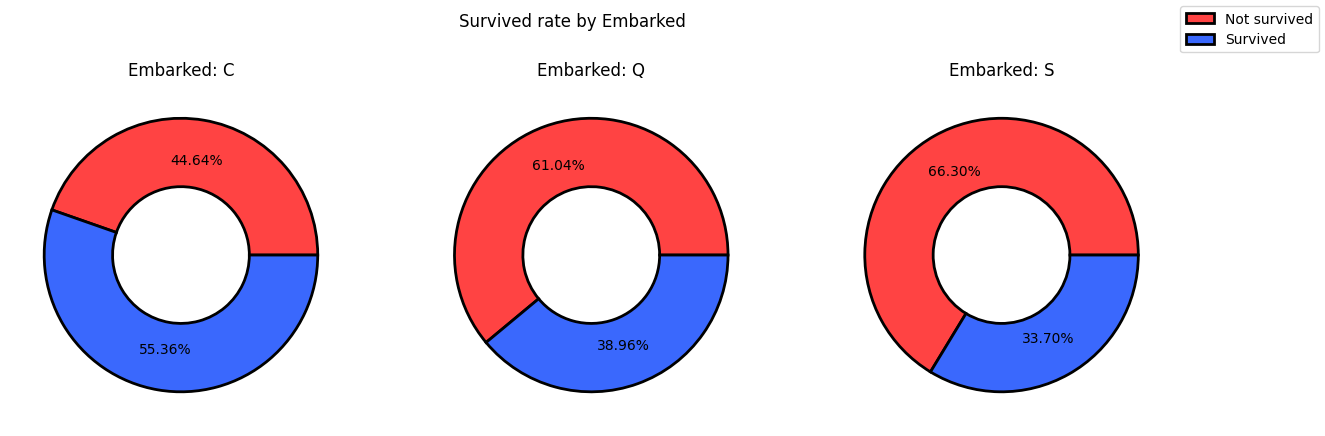

In [50]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, embarked in enumerate(group_embarked_survived.index):
    survival_values_by_embarked_type = group_embarked_survived.loc[embarked].reindex(SURVIVED_ORDER)

    ax[i].pie(
        survival_values_by_embarked_type,
        colors=SURVIVED_COLORS,
        autopct='%1.2f%%',
        pctdistance=0.7,
        wedgeprops={
            'edgecolor': 'black',
            'linewidth': 2,
            'width': 0.5
        }
    )

    ax[i].set_title(f'Embarked: {embarked}')

fig.legend(SURVIVED_ORDER_STR)

fig.suptitle('Survived rate by Embarked')

plt.savefig(FIGURES_PATH / '13_probability_of_survive_by_embarked.png', bbox_inches='tight')
plt.show()


Veamos si el lugar de embarcación pueda tener que ver con Pclass

In [51]:
value_counts_of_pclass_by_embarked = df.groupby('Embarked')['Pclass'].value_counts().unstack()
value_counts_of_pclass_by_embarked

Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


In [52]:
for embarked_site in value_counts_of_pclass_by_embarked.index:
    print(value_counts_of_pclass_by_embarked.loc[embarked_site])

Pclass
1    85
2    17
3    66
Name: C, dtype: int64
Pclass
1     2
2     3
3    72
Name: Q, dtype: int64
Pclass
1    127
2    164
3    353
Name: S, dtype: int64


Visualizar

Pclass
1    85
2    17
3    66
Name: C, dtype: int64
Pclass
1     2
2     3
3    72
Name: Q, dtype: int64
Pclass
1    127
2    164
3    353
Name: S, dtype: int64


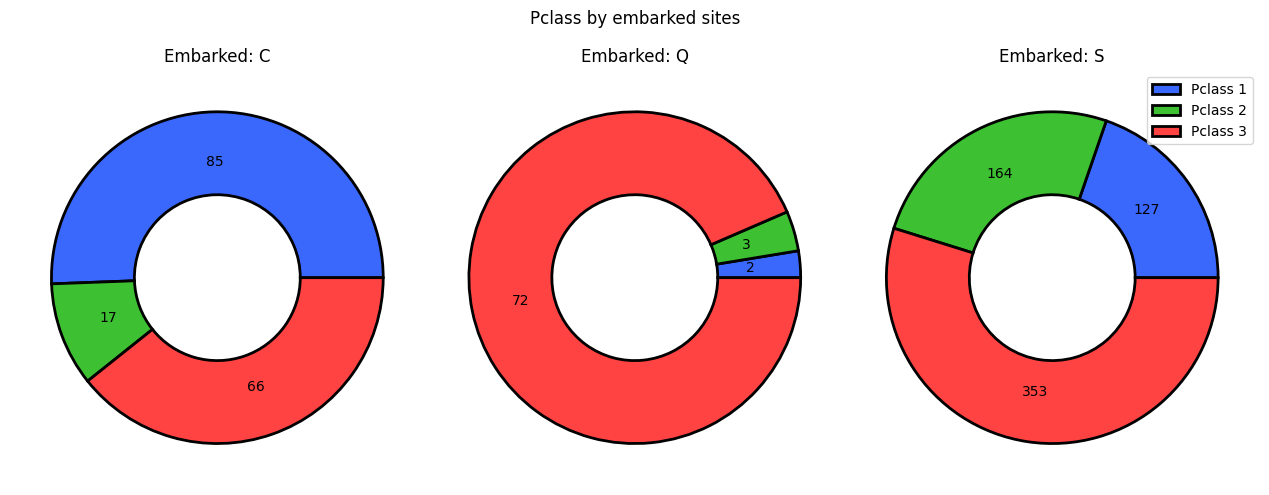

In [53]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for i, embarked_site in enumerate(value_counts_of_pclass_by_embarked.index):

    embarked_group_pclass = value_counts_of_pclass_by_embarked.loc[embarked_site].reindex([1, 2, 3])
    print(embarked_group_pclass)

    ax[i].pie(
        embarked_group_pclass,
        # Función lambda para convertir los % a número crudos utilizando regla de 3, redondeando y dejando 0 decimales.
        autopct=lambda pct: f'{np.round((pct * embarked_group_pclass.sum()) / 100):.0f}',
        colors=[SURVIVED_COLORS[1], "#3DC031", SURVIVED_COLORS[0]],
        wedgeprops={
            'width': 0.5,
            'edgecolor': 'black',
            'linewidth': 2
        },
        pctdistance=0.7
    )

    ax[i].set_title(f'Embarked: {embarked_site}')

fig.suptitle('Pclass by embarked sites')

fig.subplots_adjust(-0.5)

plt.tight_layout()

plt.legend(['Pclass 1', 'Pclass 2', 'Pclass 3'])

plt.savefig(FIGURES_PATH / '14_pclass_by_embarked.png', bbox_inches='tight')
plt.show()

# 5. Clean data

## 5.1 Age

Falta datos en "Age", pero imputaremos con mediana, por lo que queda para el proceso de separación de datos train/test y pipeline

## 5.2 Cabin

In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Como antes vimos que casi todos los Cabin son distintos y además hay muchos nulos, eliminaremos la columna

In [55]:
df = df.drop(columns=['Cabin'])

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


## 5.3 Embarked

Embarked tiene pocos nulos, simplemente rellenaremos con el valor más común pero también en train/test y pipeline

In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


## 5.4 Duplicates

Veamos si tenemos duplicados primero

In [58]:
df.duplicated().sum()

np.int64(0)

Ahora si es que hay personas con nombres duplicados

In [59]:
df['Name'].duplicated().sum()

np.int64(0)

# 6. Save

Guardar la información en clean

In [60]:
df.to_csv(PROJECT_ROOT / 'data' / 'clean' / 'clean_data.csv', index=False)